<a href="https://colab.research.google.com/github/KAREN154/PlantPathoDetect-/blob/main/Baseline_Cnn_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MODELING



To perform the modeling, CNN models were considerd for the image classififcation problem we have because of their ability of capture spatial hierarchies, reduce computational complexity, and leverage hierarchical feature learning in images. Their design principles, including local connectivity, parameter sharing, and pooling, make them particularly well-suited for processing and understanding visual data.

In [ ]:
# import Libaries
import numpy as np
import pickle
import matplotlib.pyplot as ply
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import pandas as pd
import tensorflow as tf


### Accessing Google Drive in Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Potato Data in terms of the Train, Test and Validation Data

In [ ]:
#train data generator
train_datagen = ImageDataGenerator(
         rescale=1./255)

train_potato = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/PlantPathoDetect-/data/Potato/Train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
#Val data generator
val_datagen = ImageDataGenerator(rescale = 1./255)
val_potato = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/PlantPathoDetect-/data/Potato/Val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
#Test Data Generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_potato = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/PlantPathoDetect-/data/Potato/Test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 5702 images belonging to 3 classes.
Found 1282 images belonging to 3 classes.
Found 144 images belonging to 3 classes.


### Maize Data in terms of the Train, Test and Validation Data

In [ ]:
#train data generator
train_datagen = ImageDataGenerator(
         rescale=1./255)

train_maize = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/PlantPathoDetect-/data/Corn (Maize)/Train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
#Val data generator
val_datagen = ImageDataGenerator(rescale = 1./255)
val_maize = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/PlantPathoDetect-/data/Corn (Maize)/Val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
#Test Data Generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_maize = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/PlantPathoDetect-/Corn (Maize)/Test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 4394 images belonging to 3 classes.
Found 1216 images belonging to 3 classes.
Found 136 images belonging to 3 classes.


### Tomato Data in terms of the Train, Test and Validation Data

In [ ]:
#train data generator
train_datagen = ImageDataGenerator(
         rescale=1./255)

train_tomato = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/PlantPathoDetect-/data/Tomato/Train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
#Val data generator
val_datagen = ImageDataGenerator(rescale = 1./255)
val_tomato = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/PlantPathoDetect-/data/Tomato/Val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
#Test Data Generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_tomato = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/PlantPathoDetect-/data/Tomato/Test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 11105 images belonging to 6 classes.
Found 2495 images belonging to 6 classes.
Found 280 images belonging to 6 classes.


### Models

####i. BaseLine Cnn Model

In [ ]:
def build_cnn_model(input_shape, num_classes):
    model = Sequential()

    # Convolutional Layer 1
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Convolutional Layer 2
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Convolutional Layer 3
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten and Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

input_shape = (224, 224, 3)
num_classes = 3  # Changed from 8 to 3 to match tomato dataset

model = build_cnn_model(input_shape, num_classes)

# compiling the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# # Fitting the model
# history = model.fit(train_tomato, # Changed from train_potato to train_tomato
#                     epochs=10,
#                     validation_data=val_tomato # changed from train_potato to val_tomato
# )

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Fitting the model
history = model.fit(train_potato,
                    epochs=10,
                    validation_data=val_potato
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 1671s 9s/step - accuracy: 0.6467 - loss: 0.8565 - val_accuracy: 0.9548 - val_loss: 0.1500
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 726s 4s/step - accuracy: 0.9315 - loss: 0.1863 - val_accuracy: 0.9540 - val_loss: 0.1254
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 727s 4s/step - accuracy: 0.9348 - loss: 0.1771 - val_accuracy: 0.9711 - val_loss: 0.0803
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 742s 4s/step - accuracy: 0.9672 - loss: 0.0879 - val_accuracy: 0.9782 - val_loss: 0.0574
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 741s 4s/step - accuracy: 0.9731 - loss: 0.0710 - val_accuracy: 0.9516 - val_loss: 0.1473
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 769s 4s/step - accuracy: 0.9789 - loss: 0.0547 - val_accuracy: 0.9727 - val_loss: 0.0778
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 758s 4s/step - accuracy: 0.9714 - loss: 0.0834 - val_accuracy: 0.9103 - val_loss: 0.2647
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 762s 4s/step - accuracy: 0.9757 - loss: 0.0764 - val_accuracy: 0.97

In [ ]:
# Evaluating the Test data
results = model.evaluate(test_potato, verbose=0)

print("   Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

   Test Loss: 0.02410
Test Accuracy: 99.31%


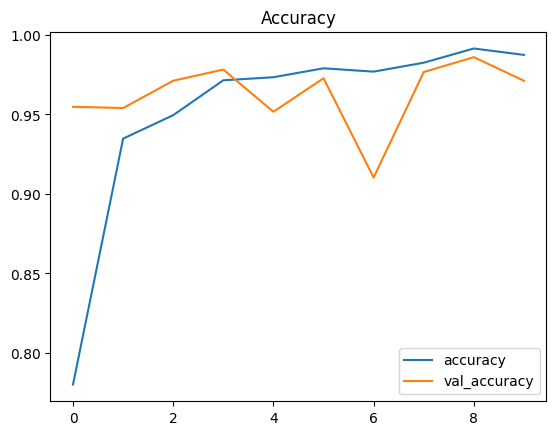

In [ ]:
# Plotting for accuracy in the model
import matplotlib.pyplot as plt
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

In [ ]:
def build_cnn_model(input_shape, num_classes):
    model = Sequential()

    # Convolutional Layer 1
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Convolutional Layer 2
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Convolutional Layer 3
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten and Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

input_shape = (224, 224, 3)
num_classes = 6  # Changed from 3 to 6 to match the actual number of classes in train_tomato

model = build_cnn_model(input_shape, num_classes)

# compiling the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Fitting the model
history = model.fit(train_tomato,
                    epochs=10,
                    validation_data=val_tomato
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


348/348 ━━━━━━━━━━━━━━━━━━━━ 3691s 10s/step - accuracy: 0.4714 - loss: 1.4268 - val_accuracy: 0.8416 - val_loss: 0.4636
Epoch 2/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1896s 5s/step - accuracy: 0.8035 - loss: 0.5437 - val_accuracy: 0.9036 - val_loss: 0.2661
Epoch 3/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1897s 5s/step - accuracy: 0.8708 - loss: 0.3545 - val_accuracy: 0.9227 - val_loss: 0.2143
Epoch 4/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1840s 5s/step - accuracy: 0.8943 - loss: 0.3024 - val_accuracy: 0.9520 - val_loss: 0.1291
Epoch 5/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1819s 5s/step - accuracy: 0.9161 - loss: 0.2354 - val_accuracy: 0.9642 - val_loss: 0.1147
Epoch 6/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1800s 5s/step - accuracy: 0.9389 - loss: 0.1826 - val_accuracy: 0.9445 - val_loss: 0.1404
Epoch 7/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1834s 5s/step - accuracy: 0.9464 - loss: 0.1527 - val_accuracy: 0.9824 - val_loss: 0.0549
Epoch 8/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 1796s 5s/step - accuracy: 0.9527 - loss: 0.1326 - val_accura

In [ ]:
# Evaluating the Test data
results = model.evaluate(test_tomato, verbose=0)

print("   Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

   Test Loss: 0.24763
Test Accuracy: 93.93%


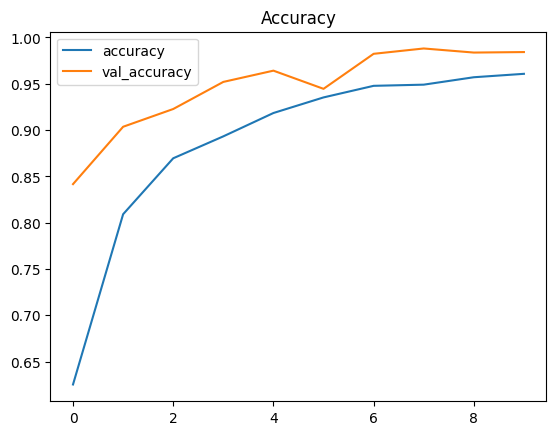

In [ ]:
# Plotting for accuracy in the model
import matplotlib.pyplot as plt
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

### Baseline Cnn Model Trained On the Maize Data

In [ ]:
def build_cnn_model(input_shape, num_classes):
    model = Sequential()

    # Convolutional Layer 1
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Convolutional Layer 2
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Convolutional Layer 3
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten and Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

input_shape = (224, 224, 3)
num_classes = 3  # Changed from 8 to 3 to match tomato dataset

model = build_cnn_model(input_shape, num_classes)

# compiling the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Fitting the Baseline Cnn model to the Train Miaze Data

### Model Evaluation on the Maize Test Data

In [ ]:
# Fitting the model
history = model.fit(train_maize,
                    epochs=10,
                    validation_data=val_maize
)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


138/138 ━━━━━━━━━━━━━━━━━━━━ 2330s 16s/step - accuracy: 0.7053 - loss: 0.7487 - val_accuracy: 0.8758 - val_loss: 0.3741
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 588s 4s/step - accuracy: 0.9404 - loss: 0.1762 - val_accuracy: 0.9137 - val_loss: 0.2340
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 617s 4s/step - accuracy: 0.9524 - loss: 0.1348 - val_accuracy: 0.9252 - val_loss: 0.1862
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 618s 4s/step - accuracy: 0.9553 - loss: 0.1206 - val_accuracy: 0.9342 - val_loss: 0.1480
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 580s 4s/step - accuracy: 0.9564 - loss: 0.1421 - val_accuracy: 0.9186 - val_loss: 0.2284
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 617s 4s/step - accuracy: 0.9626 - loss: 0.1095 - val_accuracy: 0.9367 - val_loss: 0.2043
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 578s 4s/step - accuracy: 0.9769 - loss: 0.0681 - val_accuracy: 0.9391 - val_loss: 0.1672
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 579s 4s/step - accuracy: 0.9706 - loss: 0.0892 - val_accuracy: 0.8

In [ ]:
# Evaluate the model
results = model.evaluate(test_maize, verbose=0)

print("   Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

   Test Loss: 0.28720
Test Accuracy: 91.18%


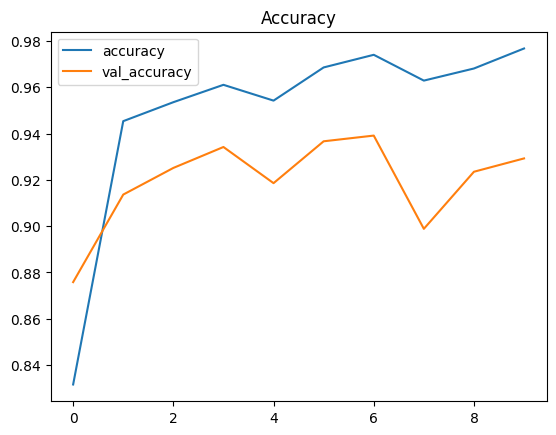

In [ ]:
# Plotting for accuracy in the model
import matplotlib.pyplot as plt
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()
plt.title("Accuracy")
plt.show()